In [1]:
import spatialdata as sd
import spatialdata_io
#import spatialdata_plot
import sparrow as sp
from sparrow.io._visium_hd import visium_hd
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import _rasterize_bins from ../utils/rasterize_bins.py
import sys
sys.path.append('../utils')
from rasterize_bins import _rasterize_bins

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribut

In [ ]:
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.n_jobs = 8
sc.settings.verbosity = 3

## Load in segmentation mask

In [ ]:
first_run = False
first_run_segm = False

if first_run:
    # FULL MICROSCOPE IMAGE
    # Use tifffile because imageio reaches dimension limits
    # We just need to transpose the channels
    import tifffile

    # Read the TIFF file
    image = tifffile.imread('../data/Visium_HD_Liver/microscope_image/SCA002_HE_hires.tif')

    # Print the shape of the image
    print("Current image shape is: {}".format(image.shape))
    image = image.transpose(1, 2, 0)
    print("New image shape is: {}".format(image.shape))

    # Save image as tif using tifffile
    tifffile.imsave('../data/Visium_HD_Liver/microscope_image/SCA002_HE_hires_transposed.tif', image)

    print("Image saved")

if first_run_segm:
    # TIFF SEGMENTATION MASK
    import rasterio
    from rasterio.features import shapes
    from shapely.geometry import shape
    import geopandas as gpd
    import numpy as np

    # Open the TIFF file
    tiff_file_path = "../data/Visium_HD_Liver/karen_segmentation_mask_stardist.tif"
    with rasterio.open(tiff_file_path) as src:
        mask = src.read(1)  # Read the first band

    # Extract shapes (polygons) from the mask
    shapes_gen = shapes(mask)
    polygons = []
    values = []

    for geom, value in shapes_gen:
        polygons.append(shape(geom))

    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame({'geometry': polygons})
    # gdf.set_crs("EPSG:4326", inplace=True, allow_override=True) # need to set this or it won't work    
    
    # Print number of shapes found
    print("Number of shapes found: {}".format(len(gdf)))

    # Save the GeoDataFrame to a json - cannot read because file is too large
    # gdf.to_file("karen_segmentation_mask_stardist.geojson", driver='GeoJSON')
    # print("GeoDataFrame saved")


Number of shapes found: 193065


In [ ]:
first_run = False

if first_run:
    sdata = spatialdata_io.visium_hd('../data/Visium_HD_Liver',
                                    fullres_image_file="microscope_image/SCA002_HE_hires_transposed.tif",
                                    annotate_table_by_labels=True)
    # Write to zarr
    sdata.write('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')
    del sdata

sdata = sd.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument '

In [ ]:
# Add segmentation mask to the spatialdata object
gdf.index=gdf.index +1

sdata=sp.sh.add_shapes_layer(
    sdata,
    input=gdf,
    output_layer="segmentation_boundaries",
)

# This takes ~30 min to run
sdata = sp.im.rasterize(sdata, shapes_layer="segmentation_boundaries", output_layer="segmentation_mask", chunks=2048)

2024-12-02 15:34:05,242 - sparrow.image._manager - WARNING - No dims parameter specified. Assuming order of dimension of provided array is ((c), (z), y, x)
2024-12-02 15:34:05,246 - sparrow.image._manager - INFO - Writing results to layer 'segmentation_mask'


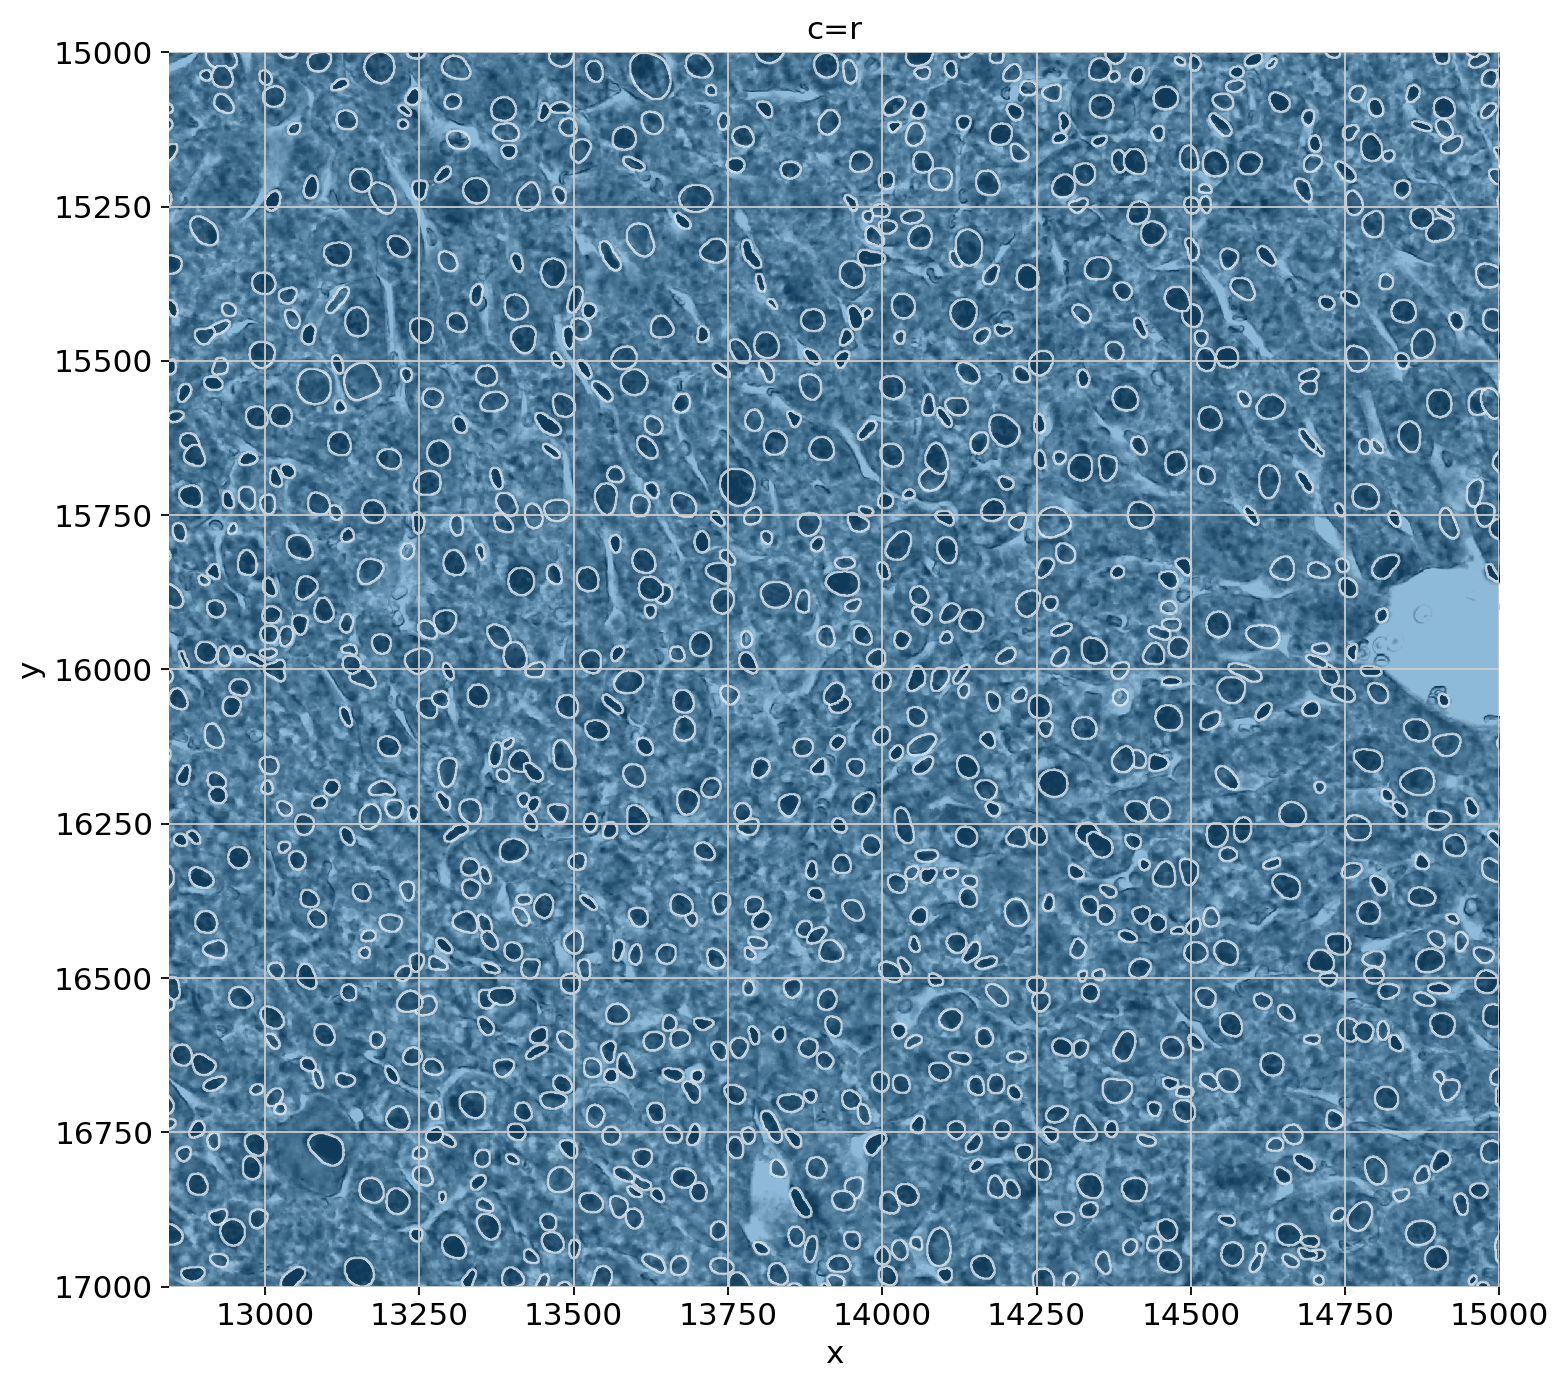

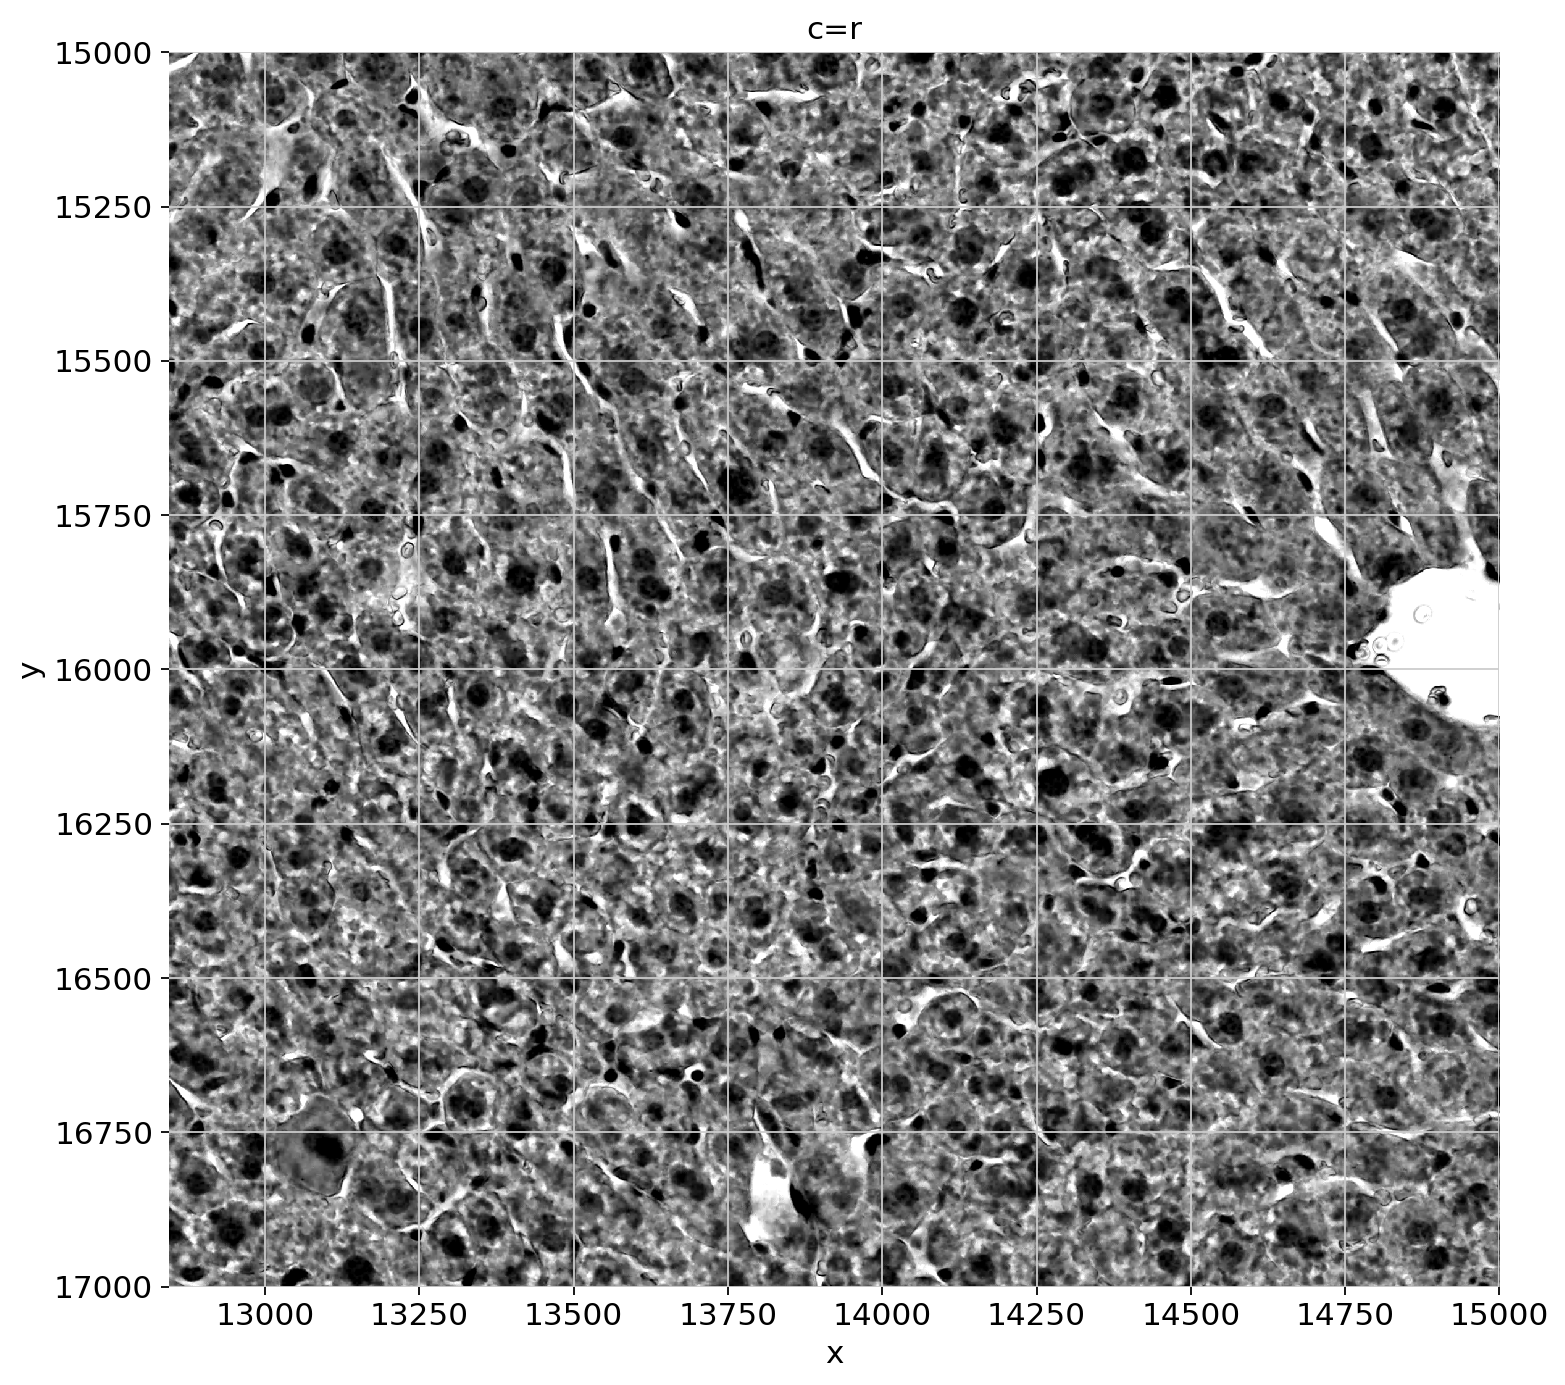

In [ ]:
sp.pl.plot_shapes(
    sdata, 
    img_layer="Visium_HD_Liver_full_image",
    shapes_layer="segmentation_boundaries",
    crd =[ 12844, 15000, 15000, 17000 ],
    figsize=(10,10) ,
    channel="r",
      )

sp.pl.plot_image(sdata,
    img_layer="Visium_HD_Liver_full_image",
    crd=[12844, 15000, 15000, 17000],
    figsize=(10,10),
    channel="r",
    )

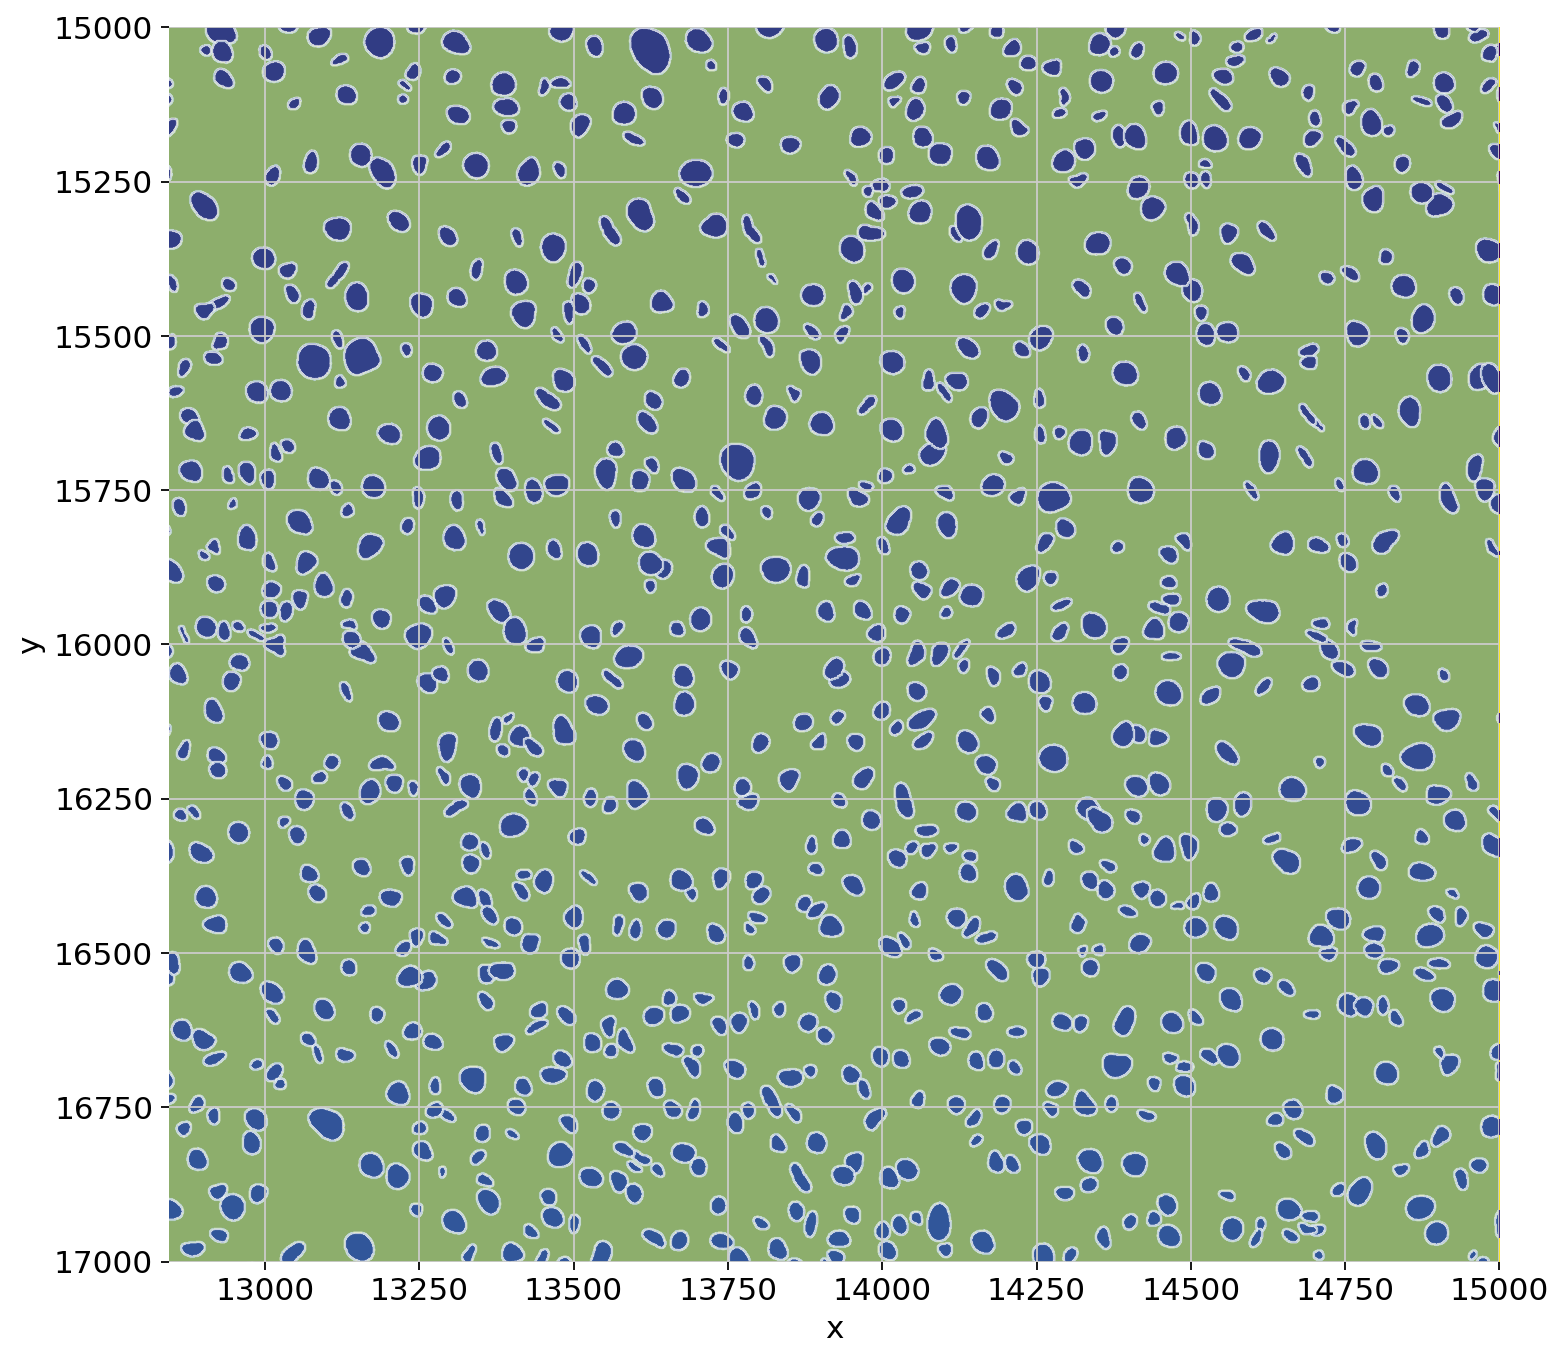

In [ ]:
# sanity plot
sp.pl.plot_shapes(
    sdata, 
    labels_layer="segmentation_mask",
    shapes_layer="segmentation_boundaries",
    crd=[12844, 15000, 15000, 17000],
    figsize=(10,10),
    channel="r",
      )

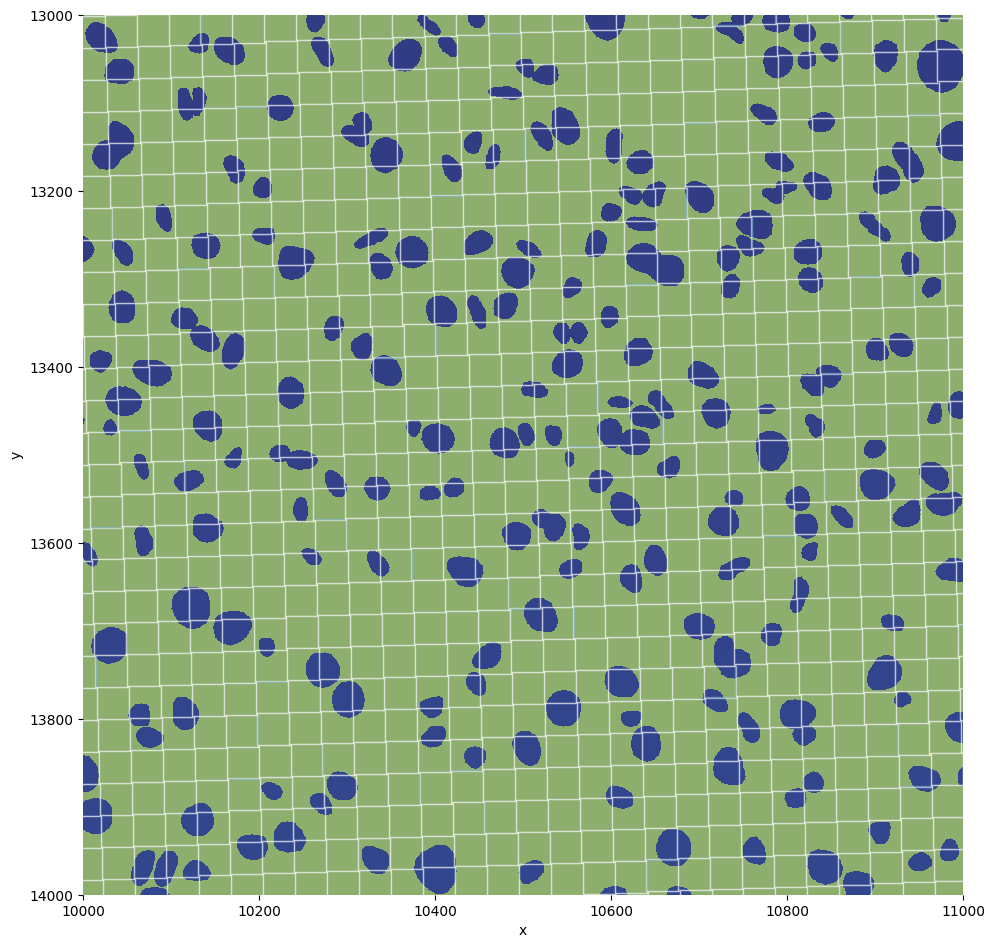

In [ ]:
# Visualizing both the grid and segmentation mask
sp.pl.plot_shapes(sdata,
                  shapes_layer= "Visium_HD_Liver_square_008um",
                  labels_layer="segmentation_mask",
                  to_coordinate_system="global",
                  crd=[10000,11000,13000,14000],
                  channel="r",
                  figsize=(10,10),
                  linewidth=1,
                  table_layer="square_008um")



There's somehow a segmented area that's super big

In [ ]:
sdata.shapes['segmentation_boundaries'].iloc[-1].geometry

In [ ]:
# Remove this from segmentation boundaries
largest_area_index = sdata.shapes['segmentation_boundaries'].geometry.area.idxmax()
sdata.shapes['segmentation_boundaries'] = sdata.shapes['segmentation_boundaries'].drop(index=largest_area_index)

shapes = sdata.shapes['segmentation_boundaries']
sdata.delete_element_from_disk('segmentation_boundaries')
del sdata.shapes['segmentation_boundaries']
sdata.shapes['segmentation_boundaries'] = shapes
sdata.write_element('segmentation_boundaries')

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/spatialdata/_core/_elements.py:96: UserWarning: Key `segmentation_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


### Smaller ROI - Figure 5.1b

In [2]:
sdata = sd.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:

In [3]:
crd = [14000,15000, 12500, 13500]

In [4]:
sdata_small = sdata.query.bounding_box(
    min_coordinate=[crd[0], crd[2]], max_coordinate=[crd[1], crd[3]], axes=("x", "y"), target_coordinate_system="global"
)

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


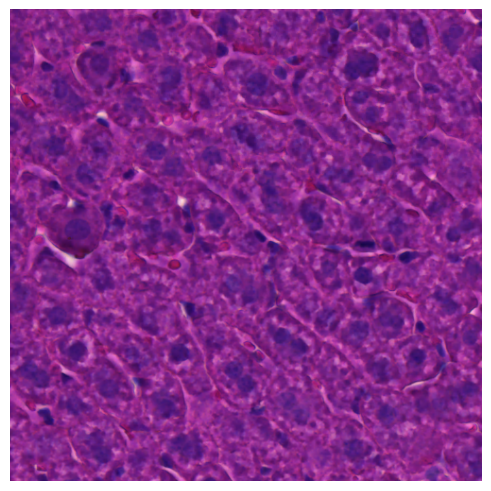

In [ ]:
import spatialdata_plot
ax = sdata_small.pl.render_images("Visium_HD_Liver_full_image").pl.show(coordinate_systems="global", return_ax=True)

# Remove axis and title
ax.axis('off')
ax.set_title('')

# Save the plot to a TIFF file
plt.savefig("plots/segmented_nuclei_roi.tiff", format="tiff", dpi=300, bbox_inches='tight')


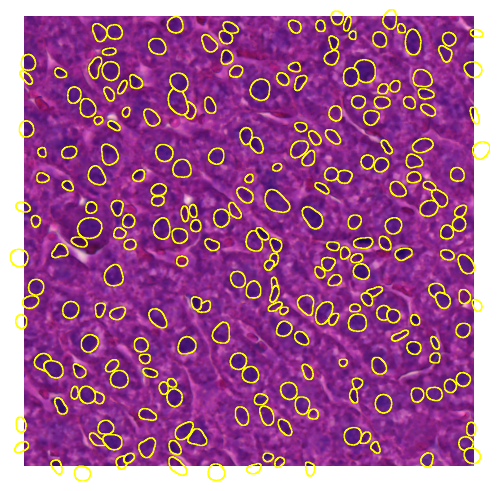

: 

In [ ]:

ax = sdata_small.pl.render_images("Visium_HD_Liver_full_image").pl.render_shapes("segmentation_boundaries", outline_color="yellow", outline_width=1, outline_alpha=1, fill_alpha=0).pl.show(coordinate_systems="global", return_ax=True)

# Remove axis and title
ax.axis('off')
ax.set_title('')

# Save the plot to a TIFF file
plt.savefig("plots/segmented_nuclei_roi_with_outline.tiff", format="tiff", dpi=300, bbox_inches='tight')


#### Save segmentation and grid (ROI) to shp file for R

In [18]:
from shapely.affinity import scale

# Flip the y-coordinates of the geometries in the segmentation_mask_boundaries
flipped_segmentation = sdata_small.shapes['segmentation_boundaries']['geometry'].apply(
    lambda geom: scale(geom, xfact=1, yfact=-1, origin=(0, 0))
)

# Save the flipped geometries to a file
flipped_segmentation.to_file('../visium_hd_liver/rds/segmentation_mask_boundaries_roi.shp')

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [ ]:
# Save grid (for R)
# Flip the y-coordinates of the geometries
flipped_geometry = sdata_small.shapes['Visium_HD_Liver_square_002um']['geometry'].apply(lambda geom: scale(geom, xfact=1, yfact=-1, origin=(0, 0)))

# Save the flipped shapes
flipped_geometry.to_file(f'../visium_hd_liver/rds/grid_2um_roi.shp')

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


### Calculate number of nuclei per 2um bin

In [4]:
# Segmentation shapes
segmentation = sdata.shapes['segmentation_boundaries']
segmentation['segmentation_id'] = segmentation.index

# Get grid shapes from sdata, and add grid_id to the grid shapes
grid_df = sdata.shapes['Visium_HD_Liver_square_002um']
grid_df['grid_id'] = grid_df.index

In [ ]:
import geopandas
# Use overlay to get intersection geometry
intersection_result = geopandas.overlay(grid_df, segmentation, how='intersection')
intersection_result = intersection_result.rename(columns={"geometry": "intersecting_geometry"})

In [6]:
intersection_result

,grid_id,value,segmentation_id,intersecting_geometry
0,4847103,73138.0,104022,"POLYGON ((10575.245 17762.57, 10566.158 17762...."
1,3093690,48692.0,50772,"POLYGON ((22769.999 12573.14, 22769.999 12578,..."
2,5880688,122707.0,127990,"POLYGON ((24881.945 20060.815, 24872.858 20060..."
3,7066355,155267.0,155774,"POLYGON ((27111.608 23199.058, 27105 23199.058..."
4,3541663,54229.0,59390,"POLYGON ((31228.582 13489.32, 31228.582 13498...."
...,...,...,...,...
2250981,4614007,87652.0,90851,"POLYGON ((28218.36 16505.812, 28209.273 16505...."
2250982,1022772,4377.0,12729,"POLYGON ((28180.238 6771.641, 28181 6771.641, ..."
2250983,6088558,119592.0,133802,"POLYGON ((23358.759 20678.731, 23356 20678.731..."
2250984,7334934,153839.0,162701,"POLYGON ((21872.297 24112.847, 21872.297 24119..."


In [ ]:
# Add original grid_geometry
# intersection_result["grid_geometry"] = grid_df.loc[intersection_result["grid_id"]].geometry.values

# Add original segmentation geometry and id
# intersection_result["segmentation_geometry"] = segmentation.loc[intersection_result["segmentation_id"]].geometry.values
# intersection_result

As you see, the `intersection_result` dataframe contains for each grid, the intersecting cell(s) and the originating cell. This is so that we can calculate the fraction of counts that the intersected cell contains. So if 30\% of the cell is in a grid, we assume that it contains 30\% of the counts of that cell. This assumption may not always hold true but for ease of computation we consider it true over the whole area.

<Axes: >

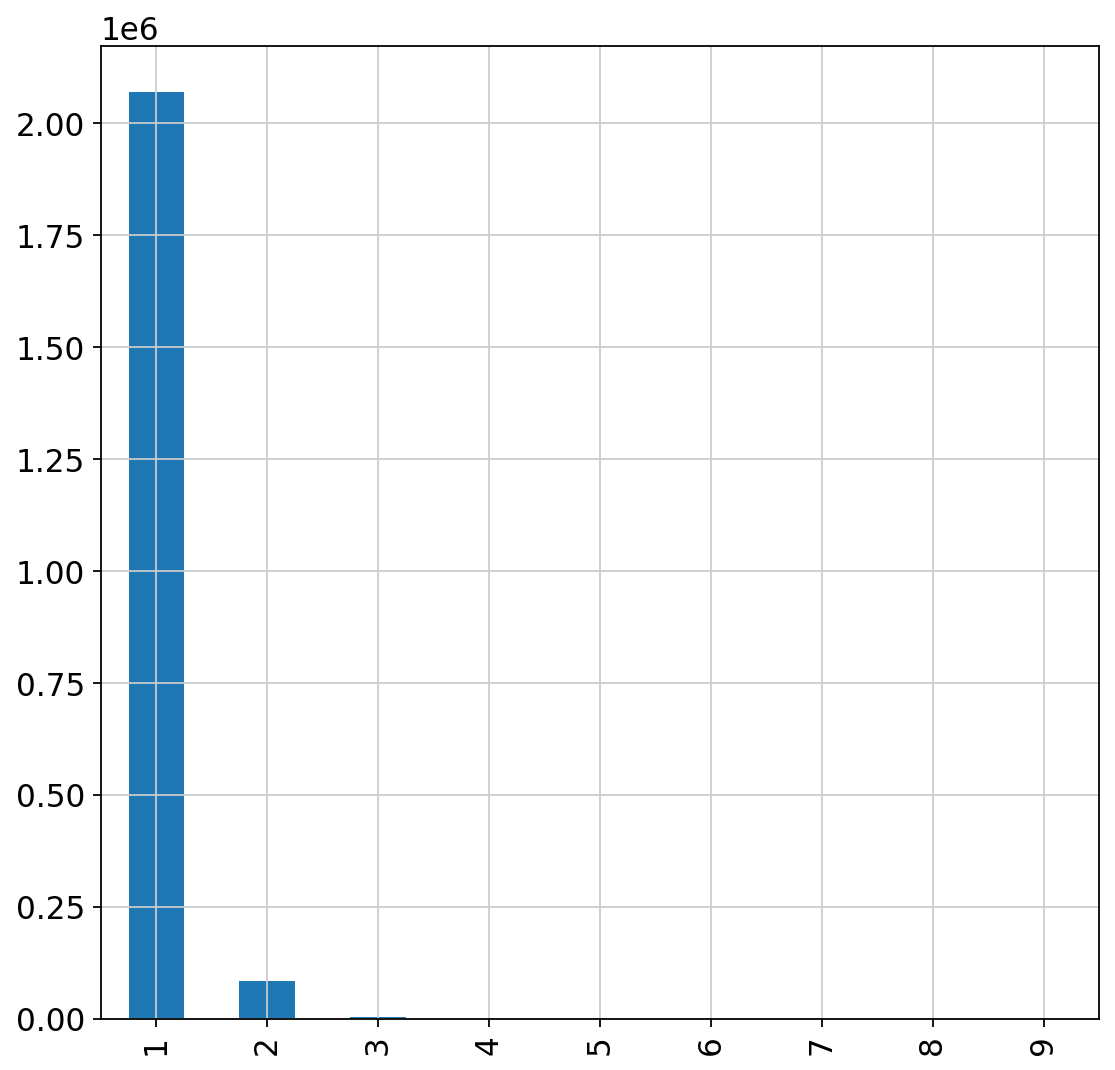

In [7]:
# What is the number of cells in each grid?
# Plot barplot of intersections.grid_id.value_counts()
cells_per_grid = intersection_result.grid_id.value_counts()
cells_per_grid = cells_per_grid.groupby(cells_per_grid.values).count()
cells_per_grid.plot(kind="bar")

In [9]:
cells_per_grid.to_csv('../visium_hd_liver/rds/nuclei_per_2um_grid.csv')

In [ ]:
# Intersect the other way
intersection_result = geopandas.overlay(segmentation, grid_df, how='intersection')
intersection_result = intersection_result.rename(columns={"geometry": "intersecting_geometry"})

In [11]:
intersection_result

,value,segmentation_id,grid_id,intersecting_geometry
0,834.0,2996,18,"POLYGON ((37196 3675, 37196 3676, 37197 3676, ..."
1,834.0,2996,17,"POLYGON ((37206 3675, 37206 3674, 37207 3674, ..."
2,834.0,2996,19,"POLYGON ((37187 3672, 37188 3672, 37188 3673, ..."
3,930.0,3012,65,"POLYGON ((36771 3684, 36775 3684, 36775 3683.5..."
4,1643.0,3028,6721,"POLYGON ((37170 3692, 37170 3693, 37176 3693, ..."
...,...,...,...,...
2250981,184364.0,193064,9982523,"POLYGON ((12250 31637.314, 12242.12 31637.314,..."
2250982,184364.0,193064,9992574,"POLYGON ((12235 31668, 12235 31669, 12236 3166..."
2250983,184364.0,193064,9985874,"POLYGON ((12242.452 31646.716, 12233.365 31646..."
2250984,184364.0,193064,9979173,"POLYGON ((12250 31637, 12249 31637, 12249 3163..."


In [ ]:
# What is the number of cells in each grid?
# Plot barplot of intersections.grid_id.value_counts()
grid_per_cells = intersection_result.segmentation_id.value_counts()

grid_per_cells = grid_per_cells.groupby(grid_per_cells.values).count()
grid_per_cells.plot(kind="bar")

segmentation_id
22339     67
13924     67
124257    63
3775      63
67142     61
          ..
33161      1
109185     1
109215     1
109308     1
10398      1
Name: count, Length: 145519, dtype: int64

In [21]:
grid_per_cells.to_csv('../visium_hd_liver/rds/grids_per_nuclei.csv')
